In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
import keras
from osgeo import gdal
import numpy as np
import cv2
import glob
from datetime import datetime
from sklearn.metrics import confusion_matrix
from sklearn.metrics import jaccard_score
import sklearn
from tensorflow.keras import models, layers, regularizers
from tensorflow.keras import backend as K

In [ ]:
path = '/content/drive/MyDrive/Colab Notebooks/Diplomatiki/Data/correct/'

X = np.load(path + 'filtered_s1_images.npy')8
y = np.load(path + 'filtered_masks.npy')

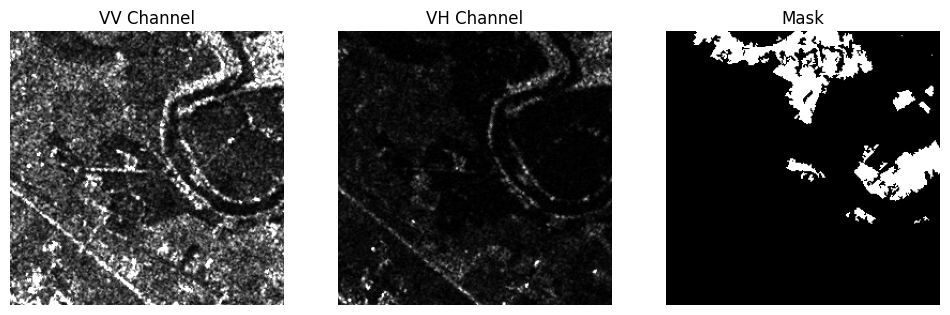

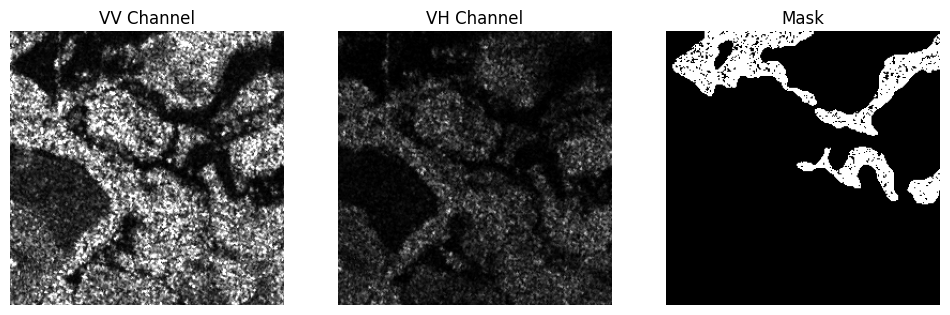

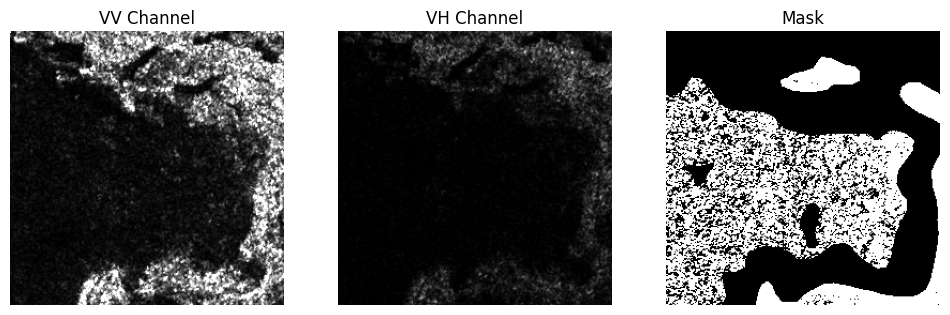

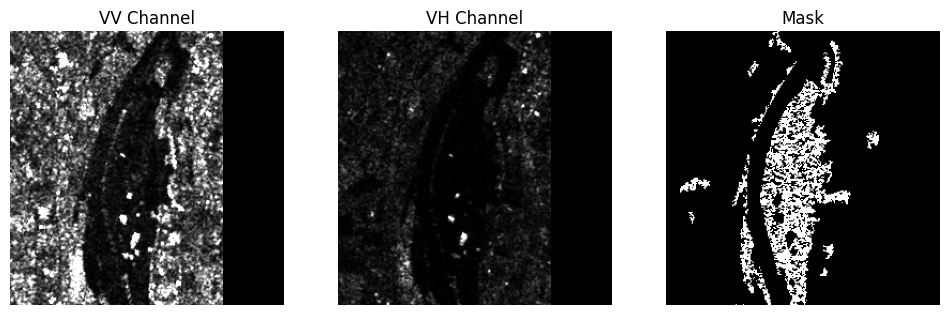

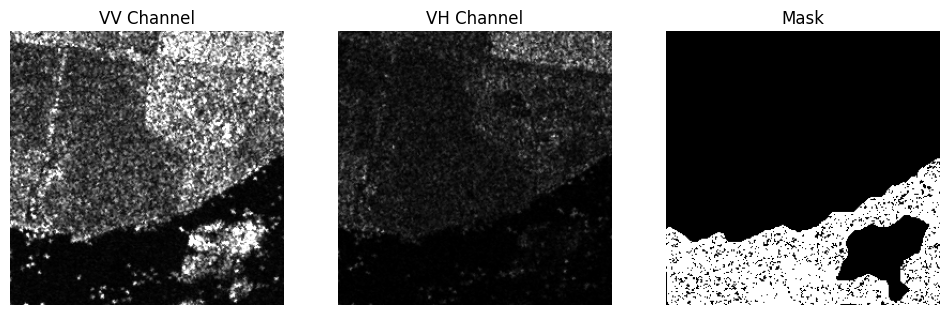

In [ ]:
# Function to visualize random images and their corresponding masks
def visualize_random_images(X_subset, Y_subset, num_images=5):
    # Get the total number of images
    total_images = X_subset.shape[0]

    # Randomly select indices without replacement
    random_indices = np.random.choice(total_images, num_images, replace=False)

    for i in random_indices:
        # Extract VV and VH channels from the satellite image
        vv = X_subset[i, :, :, 0]  # First channel (VV)
        vh = X_subset[i, :, :, 1]  # Second channel (VH)
        mask = Y_subset[i, :, :, 0]  # Corresponding mask

        # Create a figure with 3 subplots
        plt.figure(figsize=(12, 4))

        # Plot VV channel
        plt.subplot(1, 3, 1)
        plt.imshow(vv, cmap='gray')
        plt.title('VV Channel')
        plt.axis('off')

        # Plot VH channel
        plt.subplot(1, 3, 2)
        plt.imshow(vh, cmap='gray')
        plt.title('VH Channel')
        plt.axis('off')

        # Plot corresponding mask
        plt.subplot(1, 3, 3)
        plt.imshow(mask, cmap='gray')
        plt.title('Mask')
        plt.axis('off')

        # Show the plots
        plt.show()

# Visualize 5 random images and their corresponding masks
visualize_random_images(X, y, num_images=5)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, shuffle = True)

print(X_train.shape)
print(X_train.dtype)

print(y_train.shape)
print(y_train.dtype)

print(X_test.shape)
print(X_test.dtype)

print(y_test.shape)
print(y_test.dtype)

(2172, 256, 256, 2)
float32
(2172, 256, 256, 1)
uint8
(544, 256, 256, 2)
float32
(544, 256, 256, 1)
uint8


In [ ]:
X_train = (X_train - X_train.min())/(X_train.max() - X_train.min())
X_test = (X_test - X_test.min())/(X_test.max() - X_test.min())

In [ ]:
# initialize parameters
IMG_WIDTH = 256
IMG_HEIGHT = 256
IMG_CHANNELS = 2
baseNumOfFilters = 8
#baseDropoutValue = 0.1

In [ ]:
# ##########################################_STARTING THE U-NET_########################################################
# build the model
# encoding
inputs = tf.keras.layers.Input((IMG_WIDTH,IMG_HEIGHT,IMG_CHANNELS))
# s = tf.keras.layers.Lambda(lambda x: x/10000)(inputs)

c1 = tf.keras.layers.Conv2D(baseNumOfFilters, (3, 3), activation='relu', kernel_initializer='he_normal',padding='same')(inputs)
c1 = tf.keras.layers.Dropout(0.1)(c1)
c1 = tf.keras.layers.Conv2D(baseNumOfFilters, (3, 3), activation='relu', kernel_initializer='he_normal',padding='same')(c1)
p1 = tf.keras.layers.MaxPooling2D((2, 2))(c1)

c2 = tf.keras.layers.Conv2D(2*baseNumOfFilters, (3, 3), activation='relu', kernel_initializer='he_normal',padding='same')(p1)
c2 = tf.keras.layers.Dropout(0.1)(c2)
c2 = tf.keras.layers.Conv2D(2*baseNumOfFilters, (3, 3), activation='relu', kernel_initializer='he_normal',padding='same')(c2)
p2 = tf.keras.layers.MaxPooling2D((2, 2))(c2)

c3 = tf.keras.layers.Conv2D(4*baseNumOfFilters, (3, 3), activation='relu', kernel_initializer='he_normal',padding='same')(p2)
c3 = tf.keras.layers.Dropout(0.2)(c3)
c3 = tf.keras.layers.Conv2D(4*baseNumOfFilters, (3, 3), activation='relu', kernel_initializer='he_normal',padding='same')(c3)
p3 = tf.keras.layers.MaxPooling2D((2, 2))(c3)

c4 = tf.keras.layers.Conv2D(8*baseNumOfFilters, (3, 3), activation='relu', kernel_initializer='he_normal',padding='same')(p3)
c4 = tf.keras.layers.Dropout(0.2)(c4)
c4 = tf.keras.layers.Conv2D(8*baseNumOfFilters, (3, 3), activation='relu', kernel_initializer='he_normal',padding='same')(c4)
p4 = tf.keras.layers.MaxPooling2D((2, 2))(c4)

c5 = tf.keras.layers.Conv2D(16*baseNumOfFilters, (3, 3), activation='relu', kernel_initializer='he_normal',padding='same')(p4)
c5 = tf.keras.layers.Dropout(0.3)(c5)
c5 = tf.keras.layers.Conv2D(16*baseNumOfFilters, (3, 3), activation='relu', kernel_initializer='he_normal',padding='same')(c5)

# decoding
u6 = tf.keras.layers.Conv2DTranspose(8*baseNumOfFilters, (2, 2), strides=(2, 2), padding='same')(c5)
u6 = tf.keras.layers.concatenate([u6, c4])
c6 = tf.keras.layers.Conv2D(8*baseNumOfFilters, (3, 3), activation='relu', kernel_initializer='he_normal',padding='same')(u6)
c6 = tf.keras.layers.Dropout(0.2)(c6)
c6 = tf.keras.layers.Conv2D(8*baseNumOfFilters, (3, 3), activation='relu', kernel_initializer='he_normal',padding='same')(c6)

u7 = tf.keras.layers.Conv2DTranspose(4*baseNumOfFilters, (2, 2), strides=(2, 2), padding='same')(c6)
u7 = tf.keras.layers.concatenate([u7, c3])
c7 = tf.keras.layers.Conv2D(4*baseNumOfFilters, (3, 3), activation='relu', kernel_initializer='he_normal',padding='same')(u7)
c7 = tf.keras.layers.Dropout(0.2)(c7)
c7 = tf.keras.layers.Conv2D(4*baseNumOfFilters, (3, 3), activation='relu', kernel_initializer='he_normal',padding='same')(c7)

u8 = tf.keras.layers.Conv2DTranspose(2*baseNumOfFilters, (2, 2), strides=(2, 2), padding='same')(c7)
u8 = tf.keras.layers.concatenate([u8, c2])
c8 = tf.keras.layers.Conv2D(2*baseNumOfFilters, (3, 3), activation='relu', kernel_initializer='he_normal',padding='same')(u8)
c8 = tf.keras.layers.Dropout(0.1)(c8)
c8 = tf.keras.layers.Conv2D(2*baseNumOfFilters, (3, 3), activation='relu', kernel_initializer='he_normal',padding='same')(c8)

u9 = tf.keras.layers.Conv2DTranspose(baseNumOfFilters, (2, 2), strides=(2, 2), padding='same')(c8)
u9 = tf.keras.layers.concatenate([u9, c1])
c9 = tf.keras.layers.Conv2D(baseNumOfFilters, (3, 3), activation='relu', kernel_initializer='he_normal',padding='same')(u9)
c9 = tf.keras.layers.Dropout(0.1)(c9)
c9 = tf.keras.layers.Conv2D(baseNumOfFilters, (3, 3), activation='relu', kernel_initializer='he_normal',padding='same')(c9)

outputs = tf.keras.layers.Conv2D(1, (1, 1), activation='sigmoid')(c9)

model = tf.keras.Model(inputs=[inputs], outputs=[outputs])
model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Model checkpoint - save the model after every epoch
# Save best only - the latest best model will not be overwritten

results = model.fit(X_train, y_train, validation_split=0.1, batch_size=64, epochs=50)

# save the final model, once trainng is completed
model_name = 'MMFlood_unet_aplo.keras'
model.save(model_name)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 256, 256, 2)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 256, 256, 8)    │            152 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 256, 256, 8)    │              0 │ conv2d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 256, 256, 8)    │            584 │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 128, 128, 8)    │              0 │ conv2d_1[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 128, 128, 16)   │          1,168 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 128, 128, 16)   │              0 │ conv2d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 128, 128, 16)   │          2,320 │ dropout_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 64, 64, 16)     │              0 │ conv2d_3[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 64, 64, 32)     │          4,640 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_2 (Dropout)       │ (None, 64, 64, 32)     │              0 │ conv2d_4[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 64, 64, 32)     │          9,248 │ dropout_2[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_2           │ (None, 32, 32, 32)     │              0 │ conv2d_5[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 32, 32, 64)     │         18,496 │ max_pooling2d_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_3 (Dropout)       │ (None, 32, 32, 64)     │              0 │ conv2d_6[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 32, 32, 64)     │         36,928 │ dropout_3[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_3           │ (None, 16, 16, 64)     │              0 │ conv2d_7[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_8 (Conv2D)    

 Total params: 485,745 (1.85 MB)

 Trainable params: 485,745 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 53s 819ms/step - accuracy: 0.6822 - loss: 0.6043 - val_accuracy: 0.7561 - val_loss: 0.5253
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 139ms/step - accuracy: 0.7341 - loss: 0.5210 - val_accuracy: 0.7561 - val_loss: 0.4572
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 139ms/step - accuracy: 0.7349 - loss: 0.4770 - val_accuracy: 0.7631 - val_loss: 0.4377
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 139ms/step - accuracy: 0.7530 - loss: 0.4666 - val_accuracy: 0.7661 - val_loss: 0.4342
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 139ms/step - accuracy: 0.7539 - loss: 0.4517 - val_accuracy: 0.7694 - val_loss: 0.4243
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 140ms/step - accuracy: 0.7567 - loss: 0.4495 - val_accuracy: 0.7730 - val_loss: 0.4130
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 141ms/step - accuracy: 0.7671 - loss: 0.4325 - val_accuracy: 0.7770 - val_loss: 0.4177
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 140ms/step - accuracy: 0.7702 - loss: 0.4358 - val_accuracy: 0

In [ ]:
acc = []
precision =[]
recall = []
f1 = []
jac = []
k =[]


for idx in range(0,X_test.shape[0]):
    mask = y_test[idx]
    prediction = model.predict(np.expand_dims(X_test[idx], axis=0))
    prediction = np.squeeze(prediction, axis=0)
    ret, thresh_pred = cv2.threshold(prediction, prediction.mean(), 1, cv2.THRESH_BINARY)
    ret2, mask = cv2.threshold(mask, 0.5, 1, cv2.THRESH_BINARY)

    mask = list(mask.ravel())
    thresh_pred = list(thresh_pred.ravel())

    cm = confusion_matrix(mask, thresh_pred)

    if cm.shape == (2,2):
        #print(cm)

        TP = cm[0][0]
        FP = cm[0][1]
        FN = cm[1][0]
        TN = cm[1][1]

        accuracyscore = sklearn.metrics.accuracy_score(mask,thresh_pred)
        precisionscore = sklearn.metrics.precision_score(mask,thresh_pred, average='macro')
        recallscore = sklearn.metrics.recall_score(mask,thresh_pred, average='macro')
        f1score = 2*(precisionscore*recallscore)/(precisionscore + recallscore)
        jaccard = jaccard_score(mask,thresh_pred, average='macro')
        #print("accuracy", accuracyscore, "precision", precisionscore,"recall", recallscore,"f1", f1score,"jac", jaccard)
        print(accuracyscore, precisionscore, recallscore, f1score, jaccard)



acc = np.array(accuracyscore)
precision = np.array(precisionscore)
recall= np.array(recallscore)
f1 = np.array(f1score)
jac = np.array(jaccard)

print("")
print("averages:","accuracy", np.average(acc), "precision", np.average(precision),"recall", np.average(recall),"f1", np.average(f1),"jac", np.average(jac))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
0.7371673583984375 0.6417116597701944 0.743639595686171 0.6889259273979697 0.50476918712261
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
0.67431640625 0.6461401936753635 0.7591369674944475 0.6980956081214192 0.46567014250039496
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
0.788421630859375 0.670181217723407 0.8372611012139799 0.7444618706997204 0.5532215690716467
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
0.8366241455078125 0.8140193307531254 0.8611600267171997 0.8369263929783068 0.7028916789006316
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
0.694122314453125 0.5424068815074229 0.5972248311684918 0.5684974446214267 0.40778341778851046
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
0.8624725341796875 0.7369040192638842 0.9163395049402792 0.816884208907847 0.6581027428103592
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
0.519073486328125 0.5010930073429167 0.5020237947774608 0.501557969223514 0.3082251005693628
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
0.431671142578125 0.45921167969255616 0.45971

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


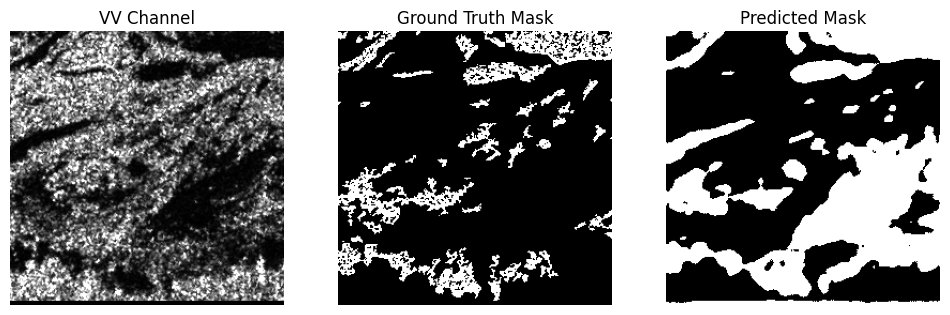

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


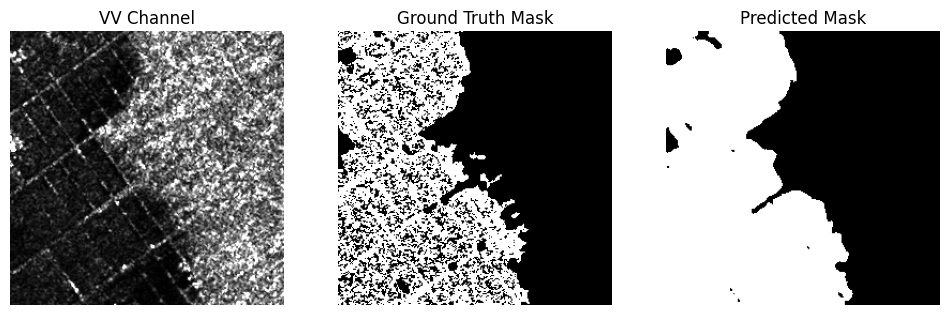

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


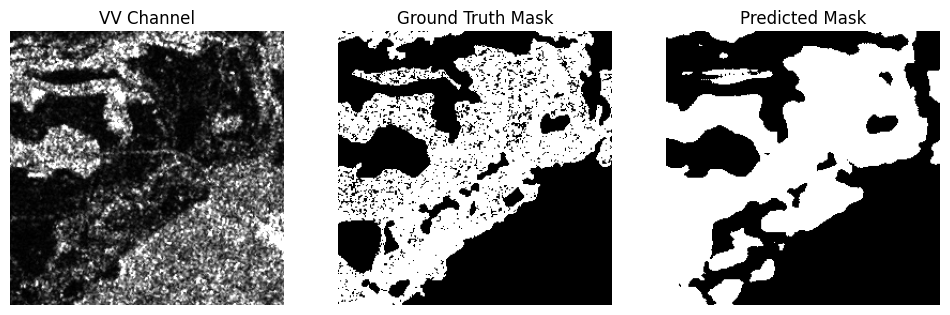

In [ ]:
# prompt: i want to make a code to visualize the prediction and the result of specific image

# Function to visualize a specific image, its ground truth mask, and the model's prediction
def visualize_prediction(image_index):
    """
    Visualizes a specific image, its ground truth mask, and the model's prediction.

    Args:
        image_index: The index of the image to visualize.
    """

    image = X_test[image_index]
    ground_truth_mask = y_test[image_index]
    prediction = model.predict(np.expand_dims(image, axis=0))
    predicted_mask = np.squeeze(prediction, axis=0)

    # Apply thresholding to the prediction
    ret, thresh_pred = cv2.threshold(predicted_mask, predicted_mask.mean(), 1, cv2.THRESH_BINARY)

    # Create a figure with 3 subplots
    plt.figure(figsize=(12, 4))

    # Plot VV channel
    plt.subplot(1, 3, 1)
    plt.imshow(image[:, :, 0], cmap='gray')
    plt.title('VV Channel')
    plt.axis('off')

    # Plot Ground truth mask
    plt.subplot(1, 3, 2)
    plt.imshow(ground_truth_mask[:, :, 0], cmap='gray')
    plt.title('Ground Truth Mask')
    plt.axis('off')

    # Plot Predicted mask
    plt.subplot(1, 3, 3)
    plt.imshow(thresh_pred, cmap='gray')
    plt.title('Predicted Mask')
    plt.axis('off')

    # Show the plots
    plt.show()

# Example usage: Visualize the prediction for the image at index 10
visualize_prediction(12)
visualize_prediction(18)
visualize_prediction(32)


In [ ]:
import pandas as pd
# Creating a Pandas DataFrame
data = {'accuracy': acc, 'precision': precision, 'recall': recall,  'f1': f1,  'jac': jac}
df = pd.DataFrame(data).dropna()

In [ ]:
df.describe().to_csv('unet.csv')

In [ ]:
"""
Attention U-net:
https://arxiv.org/pdf/1804.03999.pdf
Recurrent residual Unet (R2U-Net) paper
https://arxiv.org/ftp/arxiv/papers/1802/1802.06955.pdf
(Check fig 4.)
Note: Batch normalization should be performed over channels after a convolution,
In the following code axis is set to 3 as our inputs are of shape
[None, height, width, channel]. Channel is axis=3.
Original code from below link but heavily modified.
https://github.com/MoleImg/Attention_UNet/blob/master/AttResUNet.py
"""

# network structure
FILTER_NUM = 16 # number of basic filters for the first layer
FILTER_SIZE = 3 # size of the convolutional filter
UP_SAMP_SIZE = 2 # size of upsampling filters

'''
A few useful metrics and losses
'''

def dice_coef(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2.0 * intersection + 1.0) / (K.sum(y_true_f) + K.sum(y_pred_f) + 1.0)


def jacard_coef(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (intersection + 1.0) / (K.sum(y_true_f) + K.sum(y_pred_f) - intersection + 1.0)


def jacard_coef_loss(y_true, y_pred):
    return -jacard_coef(y_true, y_pred)


def dice_coef_loss(y_true, y_pred):
    return -dice_coef(y_true, y_pred)


##############################################################
'''
Useful blocks to build Unet
conv - BN - Activation - conv - BN - Activation - Dropout (if enabled)
'''


def conv_block(x, filter_size, size, dropout, batch_norm=False):

    conv = layers.Conv2D(size, (filter_size, filter_size), padding="same")(x)
    if batch_norm is True:
        conv = layers.BatchNormalization(axis=3)(conv)
    conv = layers.Activation("relu")(conv)

    conv = layers.Conv2D(size, (filter_size, filter_size), padding="same")(conv)
    if batch_norm is True:
        conv = layers.BatchNormalization(axis=3)(conv)
    conv = layers.Activation("relu")(conv)

    if dropout > 0:
        conv = layers.Dropout(dropout)(conv)

    return conv


def repeat_elem(tensor, rep):
    # lambda function to repeat Repeats the elements of a tensor along an axis
    #by a factor of rep.
    # If tensor has shape (None, 256,256,3), lambda will return a tensor of shape
    #(None, 256,256,6), if specified axis=3 and rep=2.

     return layers.Lambda(lambda x, repnum: K.repeat_elements(x, repnum, axis=3),
                          arguments={'repnum': rep})(tensor)


def res_conv_block(x, filter_size, size, dropout, batch_norm=False):
    '''
    Residual convolutional layer.
    Two variants....
    Either put activation function before the addition with shortcut
    or after the addition (which would be as proposed in the original resNet).

    1. conv - BN - Activation - conv - BN - Activation
                                          - shortcut  - BN - shortcut+BN

    2. conv - BN - Activation - conv - BN
                                     - shortcut  - BN - shortcut+BN - Activation

    Check fig 4 in https://arxiv.org/ftp/arxiv/papers/1802/1802.06955.pdf
    '''

    conv = layers.Conv2D(size, (filter_size, filter_size), padding='same')(x)
    if batch_norm is True:
        conv = layers.BatchNormalization(axis=3)(conv)
    conv = layers.Activation('relu')(conv)

    conv = layers.Conv2D(size, (filter_size, filter_size), padding='same')(conv)
    if batch_norm is True:
        conv = layers.BatchNormalization(axis=3)(conv)
    #conv = layers.Activation('relu')(conv)    #Activation before addition with shortcut
    if dropout > 0:
        conv = layers.Dropout(dropout)(conv)

    shortcut = layers.Conv2D(size, kernel_size=(1, 1), padding='same')(x)
    if batch_norm is True:
        shortcut = layers.BatchNormalization(axis=3)(shortcut)

    res_path = layers.add([shortcut, conv])
    res_path = layers.Activation('relu')(res_path)    #Activation after addition with shortcut (Original residual block)
    return res_path

def gating_signal(input, out_size, batch_norm=False):
    """
    resize the down layer feature map into the same dimension as the up layer feature map
    using 1x1 conv
    :return: the gating feature map with the same dimension of the up layer feature map
    """
    x = layers.Conv2D(out_size, (1, 1), padding='same')(input)
    if batch_norm:
        x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    return x

def attention_block(x, gating, inter_shape):
    shape_x = K.int_shape(x)
    shape_g = K.int_shape(gating)

# Getting the x signal to the same shape as the gating signal
    theta_x = layers.Conv2D(inter_shape, (2, 2), strides=(2, 2), padding='same')(x)  # 16
    shape_theta_x = K.int_shape(theta_x)

# Getting the gating signal to the same number of filters as the inter_shape
    phi_g = layers.Conv2D(inter_shape, (1, 1), padding='same')(gating)
    upsample_g = layers.Conv2DTranspose(inter_shape, (3, 3),
                                 strides=(shape_theta_x[1] // shape_g[1], shape_theta_x[2] // shape_g[2]),
                                 padding='same')(phi_g)  # 16

    concat_xg = layers.add([upsample_g, theta_x])
    act_xg = layers.Activation('relu')(concat_xg)
    psi = layers.Conv2D(1, (1, 1), padding='same')(act_xg)
    sigmoid_xg = layers.Activation('sigmoid')(psi)
    shape_sigmoid = K.int_shape(sigmoid_xg)
    upsample_psi = layers.UpSampling2D(size=(shape_x[1] // shape_sigmoid[1], shape_x[2] // shape_sigmoid[2]))(sigmoid_xg)  # 32

    upsample_psi = repeat_elem(upsample_psi, shape_x[3])

    y = layers.multiply([upsample_psi, x])

    result = layers.Conv2D(shape_x[3], (1, 1), padding='same')(y)
    result_bn = layers.BatchNormalization()(result)
    return result_bn

def UNet(input_shape, NUM_CLASSES=1, dropout_rate=0.0, batch_norm=True):
    '''
    UNet,

    '''

    inputs = layers.Input(input_shape, dtype=tf.float32)

    # Downsampling layers
    # DownRes 1, convolution + pooling
    conv_128 = conv_block(inputs, FILTER_SIZE, FILTER_NUM, dropout_rate, batch_norm)
    pool_64 = layers.MaxPooling2D(pool_size=(2,2))(conv_128)
    # DownRes 2
    conv_64 = conv_block(pool_64, FILTER_SIZE, 2*FILTER_NUM, dropout_rate, batch_norm)
    pool_32 = layers.MaxPooling2D(pool_size=(2,2))(conv_64)
    # DownRes 3
    conv_32 = conv_block(pool_32, FILTER_SIZE, 4*FILTER_NUM, dropout_rate, batch_norm)
    pool_16 = layers.MaxPooling2D(pool_size=(2,2))(conv_32)
    # DownRes 4
    conv_16 = conv_block(pool_16, FILTER_SIZE, 8*FILTER_NUM, dropout_rate, batch_norm)
    pool_8 = layers.MaxPooling2D(pool_size=(2,2))(conv_16)
    # DownRes 5, convolution only
    conv_8 = conv_block(pool_8, FILTER_SIZE, 16*FILTER_NUM, dropout_rate, batch_norm)

    # Upsampling layers

    up_16 = layers.UpSampling2D(size=(UP_SAMP_SIZE, UP_SAMP_SIZE), data_format="channels_last")(conv_8)
    up_16 = layers.concatenate([up_16, conv_16], axis=3)
    up_conv_16 = conv_block(up_16, FILTER_SIZE, 8*FILTER_NUM, dropout_rate, batch_norm)
    # UpRes 7

    up_32 = layers.UpSampling2D(size=(UP_SAMP_SIZE, UP_SAMP_SIZE), data_format="channels_last")(up_conv_16)
    up_32 = layers.concatenate([up_32, conv_32], axis=3)
    up_conv_32 = conv_block(up_32, FILTER_SIZE, 4*FILTER_NUM, dropout_rate, batch_norm)
    # UpRes 8

    up_64 = layers.UpSampling2D(size=(UP_SAMP_SIZE, UP_SAMP_SIZE), data_format="channels_last")(up_conv_32)
    up_64 = layers.concatenate([up_64, conv_64], axis=3)
    up_conv_64 = conv_block(up_64, FILTER_SIZE, 2*FILTER_NUM, dropout_rate, batch_norm)
    # UpRes 9

    up_128 = layers.UpSampling2D(size=(UP_SAMP_SIZE, UP_SAMP_SIZE), data_format="channels_last")(up_conv_64)
    up_128 = layers.concatenate([up_128, conv_128], axis=3)
    up_conv_128 = conv_block(up_128, FILTER_SIZE, FILTER_NUM, dropout_rate, batch_norm)

    # 1*1 convolutional layers

    conv_final = layers.Conv2D(NUM_CLASSES, kernel_size=(1,1))(up_conv_128)
    conv_final = layers.BatchNormalization(axis=3)(conv_final)
    conv_final = layers.Activation('sigmoid')(conv_final)  #Change to softmax for multichannel

    # Model
    model = models.Model(inputs, conv_final, name="UNet")
    print(model.summary())
    return model

def R2UNet(input_shape, NUM_CLASSES=1, dropout_rate=0.0, batch_norm=True):
    '''
    R2UNet,

    '''

    inputs = layers.Input(input_shape, dtype=tf.float32)

    # Downsampling layers
    # DownRes 1, convolution + pooling
    conv_128 = res_conv_block(inputs, FILTER_SIZE, FILTER_NUM, dropout_rate, batch_norm)
    pool_64 = layers.MaxPooling2D(pool_size=(2,2))(conv_128)
    # DownRes 2
    conv_64 = res_conv_block(pool_64, FILTER_SIZE, 2*FILTER_NUM, dropout_rate, batch_norm)
    pool_32 = layers.MaxPooling2D(pool_size=(2,2))(conv_64)
    # DownRes 3
    conv_32 = res_conv_block(pool_32, FILTER_SIZE, 4*FILTER_NUM, dropout_rate, batch_norm)
    pool_16 = layers.MaxPooling2D(pool_size=(2,2))(conv_32)
    # DownRes 4
    conv_16 = res_conv_block(pool_16, FILTER_SIZE, 8*FILTER_NUM, dropout_rate, batch_norm)
    pool_8 = layers.MaxPooling2D(pool_size=(2,2))(conv_16)
    # DownRes 5, convolution only
    conv_8 = res_conv_block(pool_8, FILTER_SIZE, 16*FILTER_NUM, dropout_rate, batch_norm)

    # Upsampling layers

    up_16 = layers.UpSampling2D(size=(UP_SAMP_SIZE, UP_SAMP_SIZE), data_format="channels_last")(conv_8)
    up_16 = layers.concatenate([up_16, conv_16], axis=3)
    up_conv_16 = res_conv_block(up_16, FILTER_SIZE, 8*FILTER_NUM, dropout_rate, batch_norm)
    # UpRes 7

    up_32 = layers.UpSampling2D(size=(UP_SAMP_SIZE, UP_SAMP_SIZE), data_format="channels_last")(up_conv_16)
    up_32 = layers.concatenate([up_32, conv_32], axis=3)
    up_conv_32 = res_conv_block(up_32, FILTER_SIZE, 4*FILTER_NUM, dropout_rate, batch_norm)
    # UpRes 8

    up_64 = layers.UpSampling2D(size=(UP_SAMP_SIZE, UP_SAMP_SIZE), data_format="channels_last")(up_conv_32)
    up_64 = layers.concatenate([up_64, conv_64], axis=3)
    up_conv_64 = res_conv_block(up_64, FILTER_SIZE, 2*FILTER_NUM, dropout_rate, batch_norm)
    # UpRes 9

    up_128 = layers.UpSampling2D(size=(UP_SAMP_SIZE, UP_SAMP_SIZE), data_format="channels_last")(up_conv_64)
    up_128 = layers.concatenate([up_128, conv_128], axis=3)
    up_conv_128 = res_conv_block(up_128, FILTER_SIZE, FILTER_NUM, dropout_rate, batch_norm)

    # 1*1 convolutional layers

    conv_final = layers.Conv2D(NUM_CLASSES, kernel_size=(1,1))(up_conv_128)
    conv_final = layers.BatchNormalization(axis=3)(conv_final)
    conv_final = layers.Activation('sigmoid')(conv_final)  #Change to softmax for multichannel

    # Model
    model = models.Model(inputs, conv_final, name="UNet")
    print(model.summary())
    return model

def Attention_UNet(input_shape, NUM_CLASSES=1, dropout_rate=0.0, batch_norm=True):
    '''
    Attention UNet,

    '''


    inputs = layers.Input(input_shape, dtype=tf.float32)

    # Downsampling layers
    # DownRes 1, convolution + pooling
    conv_128 = conv_block(inputs, FILTER_SIZE, FILTER_NUM, dropout_rate, batch_norm)
    pool_64 = layers.MaxPooling2D(pool_size=(2,2))(conv_128)
    # DownRes 2
    conv_64 = conv_block(pool_64, FILTER_SIZE, 2*FILTER_NUM, dropout_rate, batch_norm)
    pool_32 = layers.MaxPooling2D(pool_size=(2,2))(conv_64)
    # DownRes 3
    conv_32 = conv_block(pool_32, FILTER_SIZE, 4*FILTER_NUM, dropout_rate, batch_norm)
    pool_16 = layers.MaxPooling2D(pool_size=(2,2))(conv_32)
    # DownRes 4
    conv_16 = conv_block(pool_16, FILTER_SIZE, 8*FILTER_NUM, dropout_rate, batch_norm)
    pool_8 = layers.MaxPooling2D(pool_size=(2,2))(conv_16)
    # DownRes 5, convolution only
    conv_8 = conv_block(pool_8, FILTER_SIZE, 16*FILTER_NUM, dropout_rate, batch_norm)

    # Upsampling layers
    # UpRes 6, attention gated concatenation + upsampling + double residual convolution
    gating_16 = gating_signal(conv_8, 8*FILTER_NUM, batch_norm)
    att_16 = attention_block(conv_16, gating_16, 8*FILTER_NUM)
    up_16 = layers.UpSampling2D(size=(UP_SAMP_SIZE, UP_SAMP_SIZE), data_format="channels_last")(conv_8)
    up_16 = layers.concatenate([up_16, att_16], axis=3)
    up_conv_16 = conv_block(up_16, FILTER_SIZE, 8*FILTER_NUM, dropout_rate, batch_norm)
    # UpRes 7
    gating_32 = gating_signal(up_conv_16, 4*FILTER_NUM, batch_norm)
    att_32 = attention_block(conv_32, gating_32, 4*FILTER_NUM)
    up_32 = layers.UpSampling2D(size=(UP_SAMP_SIZE, UP_SAMP_SIZE), data_format="channels_last")(up_conv_16)
    up_32 = layers.concatenate([up_32, att_32], axis=3)
    up_conv_32 = conv_block(up_32, FILTER_SIZE, 4*FILTER_NUM, dropout_rate, batch_norm)
    # UpRes 8
    gating_64 = gating_signal(up_conv_32, 2*FILTER_NUM, batch_norm)
    att_64 = attention_block(conv_64, gating_64, 2*FILTER_NUM)
    up_64 = layers.UpSampling2D(size=(UP_SAMP_SIZE, UP_SAMP_SIZE), data_format="channels_last")(up_conv_32)
    up_64 = layers.concatenate([up_64, att_64], axis=3)
    up_conv_64 = conv_block(up_64, FILTER_SIZE, 2*FILTER_NUM, dropout_rate, batch_norm)
    # UpRes 9
    gating_128 = gating_signal(up_conv_64, FILTER_NUM, batch_norm)
    att_128 = attention_block(conv_128, gating_128, FILTER_NUM)
    up_128 = layers.UpSampling2D(size=(UP_SAMP_SIZE, UP_SAMP_SIZE), data_format="channels_last")(up_conv_64)
    up_128 = layers.concatenate([up_128, att_128], axis=3)
    up_conv_128 = conv_block(up_128, FILTER_SIZE, FILTER_NUM, dropout_rate, batch_norm)

    # 1*1 convolutional layers
    conv_final = layers.Conv2D(NUM_CLASSES, kernel_size=(1,1))(up_conv_128)
    conv_final = layers.BatchNormalization(axis=3)(conv_final)
    conv_final = layers.Activation('sigmoid')(conv_final)  #Change to softmax for multichannel

    # Model integration
    model = models.Model(inputs, conv_final, name="Attention_UNet")
    return model

def Attention_ResUNet(input_shape, NUM_CLASSES=1, dropout_rate=0.0, batch_norm=True):
    '''
    Rsidual UNet, with attention

    '''
    # input data
    # dimension of the image depth
    inputs = layers.Input(input_shape, dtype=tf.float32)
    axis = 3

    # Downsampling layers
    # DownRes 1, double residual convolution + pooling
    conv_128 = res_conv_block(inputs, FILTER_SIZE, FILTER_NUM, dropout_rate, batch_norm)
    pool_64 = layers.MaxPooling2D(pool_size=(2,2))(conv_128)
    # DownRes 2
    conv_64 = res_conv_block(pool_64, FILTER_SIZE, 2*FILTER_NUM, dropout_rate, batch_norm)
    pool_32 = layers.MaxPooling2D(pool_size=(2,2))(conv_64)
    # DownRes 3
    conv_32 = res_conv_block(pool_32, FILTER_SIZE, 4*FILTER_NUM, dropout_rate, batch_norm)
    pool_16 = layers.MaxPooling2D(pool_size=(2,2))(conv_32)
    # DownRes 4
    conv_16 = res_conv_block(pool_16, FILTER_SIZE, 8*FILTER_NUM, dropout_rate, batch_norm)
    pool_8 = layers.MaxPooling2D(pool_size=(2,2))(conv_16)
    # DownRes 5, convolution only
    conv_8 = res_conv_block(pool_8, FILTER_SIZE, 16*FILTER_NUM, dropout_rate, batch_norm)

    # Upsampling layers
    # UpRes 6, attention gated concatenation + upsampling + double residual convolution
    gating_16 = gating_signal(conv_8, 8*FILTER_NUM, batch_norm)
    att_16 = attention_block(conv_16, gating_16, 8*FILTER_NUM)
    up_16 = layers.UpSampling2D(size=(UP_SAMP_SIZE, UP_SAMP_SIZE), data_format="channels_last")(conv_8)
    up_16 = layers.concatenate([up_16, att_16], axis=axis)
    up_conv_16 = res_conv_block(up_16, FILTER_SIZE, 8*FILTER_NUM, dropout_rate, batch_norm)
    # UpRes 7
    gating_32 = gating_signal(up_conv_16, 4*FILTER_NUM, batch_norm)
    att_32 = attention_block(conv_32, gating_32, 4*FILTER_NUM)
    up_32 = layers.UpSampling2D(size=(UP_SAMP_SIZE, UP_SAMP_SIZE), data_format="channels_last")(up_conv_16)
    up_32 = layers.concatenate([up_32, att_32], axis=axis)
    up_conv_32 = res_conv_block(up_32, FILTER_SIZE, 4*FILTER_NUM, dropout_rate, batch_norm)
    # UpRes 8
    gating_64 = gating_signal(up_conv_32, 2*FILTER_NUM, batch_norm)
    att_64 = attention_block(conv_64, gating_64, 2*FILTER_NUM)
    up_64 = layers.UpSampling2D(size=(UP_SAMP_SIZE, UP_SAMP_SIZE), data_format="channels_last")(up_conv_32)
    up_64 = layers.concatenate([up_64, att_64], axis=axis)
    up_conv_64 = res_conv_block(up_64, FILTER_SIZE, 2*FILTER_NUM, dropout_rate, batch_norm)
    # UpRes 9
    gating_128 = gating_signal(up_conv_64, FILTER_NUM, batch_norm)
    att_128 = attention_block(conv_128, gating_128, FILTER_NUM)
    up_128 = layers.UpSampling2D(size=(UP_SAMP_SIZE, UP_SAMP_SIZE), data_format="channels_last")(up_conv_64)
    up_128 = layers.concatenate([up_128, att_128], axis=axis)
    up_conv_128 = res_conv_block(up_128, FILTER_SIZE, FILTER_NUM, dropout_rate, batch_norm)

    # 1*1 convolutional layers

    conv_final = layers.Conv2D(NUM_CLASSES, kernel_size=(1,1))(up_conv_128)
    conv_final = layers.BatchNormalization(axis=axis)(conv_final)
    conv_final = layers.Activation('sigmoid')(conv_final)  #Change to softmax for multichannel

    # Model integration
    model = models.Model(inputs, conv_final, name="AttentionResUNet")
    return model


In [ ]:
IMG_WIDTH = X_train.shape[1]
IMG_HEIGHT = X_train.shape[2]
IMG_CHANNELS = X_train.shape[3]

num_labels = 1  #Binary
input_shape = (IMG_HEIGHT,IMG_WIDTH,IMG_CHANNELS)
print(input_shape)
batch_size = 64
epochs = 50

(256, 256, 2)


In [ ]:
res_model = R2UNet(input_shape)
res_model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])
res_model.summary()

res_model_results = res_model.fit(X_train, y_train, validation_split=0.1, batch_size=batch_size, epochs=epochs)


acc = []
precision =[]
recall = []
f1 = []
jac = []
k =[]

start5_test = datetime.now()

for idx in range(0,X_test.shape[0]):
    mask = y_test[idx]
    prediction = res_model.predict(np.expand_dims(X_test[idx], axis=0))
    prediction = np.squeeze(prediction, axis=0)
    ret, thresh_pred = cv2.threshold(prediction, prediction.mean(), 1, cv2.THRESH_BINARY)
    ret2, mask = cv2.threshold(mask, 0.5, 1, cv2.THRESH_BINARY)

    mask = list(mask.ravel())
    thresh_pred = list(thresh_pred.ravel())

    cm = confusion_matrix(mask, thresh_pred)

    if cm.shape == (2,2):
        #print(cm)

        TP = cm[0][0]
        FP = cm[0][1]
        FN = cm[1][0]
        TN = cm[1][1]

        accuracyscore = sklearn.metrics.accuracy_score(mask,thresh_pred)
        precisionscore = sklearn.metrics.precision_score(mask,thresh_pred, average='macro')
        recallscore = sklearn.metrics.recall_score(mask,thresh_pred, average='macro')
        f1score = 2*(precisionscore*recallscore)/(precisionscore + recallscore)
        jaccard = jaccard_score(mask,thresh_pred, average='macro')

            #print('stats ; ',idx, ';', accuracyscore, ';', precisionscore, ';', recallscore, ';', f1score, ';', jaccard, ';',kappa)
        acc.append(accuracyscore)
        precision.append(precisionscore)
        recall.append(recallscore)
        f1.append(f1score)
        jac.append(jaccard)

acc = np.array(acc)
precision = np.array(precision)
recall= np.array(recall)
f1 = np.array(f1)
jac = np.array(jac)
print("")
print("averages:","accuracy", np.average(acc), "precision", np.average(precision),"recall", np.average(recall),"f1", np.average(f1),"jac", np.average(jac))


Model: "UNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 256, 256, 2)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_19 (Conv2D)        │ (None, 256, 256, 16)   │            304 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 256, 256, 16)   │             64 │ conv2d_19[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation (Activation)   │ (None, 256, 256, 16)   │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_21 (Conv2D)        │ (None, 256, 256, 16)   │             48 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_20 (Conv2D)        │ (None, 256, 256, 16)   │          2,320 │ activation[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 256, 256, 16)   │             64 │ conv2d_21[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 256, 256, 16)   │             64 │ conv2d_20[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 256, 256, 16)   │              0 │ batch_normalization_2… │
│                           │                        │                │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_1 (Activation) │ (None, 256, 256, 16)   │              0 │ add[0][0]              │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_4           │ (None, 128, 128, 16)   │              0 │ activation_1[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_22 (Conv2D)        │ (None, 128, 128, 32)   │          4,640 │ max_pooling2d_4[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 128, 128, 32)   │            128 │ conv2d_22[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_2 (Activation) │ (None, 128, 128, 32)   │              0 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_24 (Conv2D)        │ (None, 128, 128, 32)   │            544 │ max_pooling2d_4[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_23 (Conv2D)        │ (None, 128, 128, 32)   │          9,248 │ activation_2[0][0]     │
├──────────────────────

 Total params: 2,080,885 (7.94 MB)

 Trainable params: 2,076,467 (7.92 MB)

 Non-trainable params: 4,418 (17.26 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 256, 256, 2)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_19 (Conv2D)        │ (None, 256, 256, 16)   │            304 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 256, 256, 16)   │             64 │ conv2d_19[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation (Activation)   │ (None, 256, 256, 16)   │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_21 (Conv2D)        │ (None, 256, 256, 16)   │             48 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_20 (Conv2D)        │ (None, 256, 256, 16)   │          2,320 │ activation[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 256, 256, 16)   │             64 │ conv2d_21[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 256, 256, 16)   │             64 │ conv2d_20[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 256, 256, 16)   │              0 │ batch_normalization_2… │
│                           │                        │                │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_1 (Activation) │ (None, 256, 256, 16)   │              0 │ add[0][0]              │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_4           │ (None, 128, 128, 16)   │              0 │ activation_1[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_22 (Conv2D)        │ (None, 128, 128, 32)   │          4,640 │ max_pooling2d_4[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 128, 128, 32)   │            128 │ conv2d_22[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_2 (Activation) │ (None, 128, 128, 32)   │              0 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_24 (Conv2D)        │ (None, 128, 128, 32)   │            544 │ max_pooling2d_4[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_23 (Conv2D)        │ (None, 128, 128, 32)   │          9,248 │ activation_2[0][0]     │
├──────────────────────

 Total params: 2,080,885 (7.94 MB)

 Trainable params: 2,076,467 (7.92 MB)

 Non-trainable params: 4,418 (17.26 KB)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.6887 - loss: 0.6316 - val_accuracy: 0.7561 - val_loss: 1.1206
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 388ms/step - accuracy: 0.7725 - loss: 0.5508 - val_accuracy: 0.7561 - val_loss: 0.6394
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 391ms/step - accuracy: 0.7805 - loss: 0.5343 - val_accuracy: 0.7561 - val_loss: 0.6037
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 390ms/step - accuracy: 0.7915 - loss: 0.5197 - val_accuracy: 0.7561 - val_loss: 0.5567
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 389ms/step - accuracy: 0.7931 - loss: 0.5087 - val_accuracy: 0.7561 - val_loss: 0.6148
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 389ms/step - accuracy: 0.7868 - loss: 0.5118 - val_accuracy: 0.7561 - val_loss: 0.6645
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 387ms/step - accuracy: 0.7881 - loss: 0.5010 - val_accuracy: 0.7561 - val_loss: 0.6007
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 387ms/step - accuracy: 0.7955 - loss: 0.4890 - val_accura

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


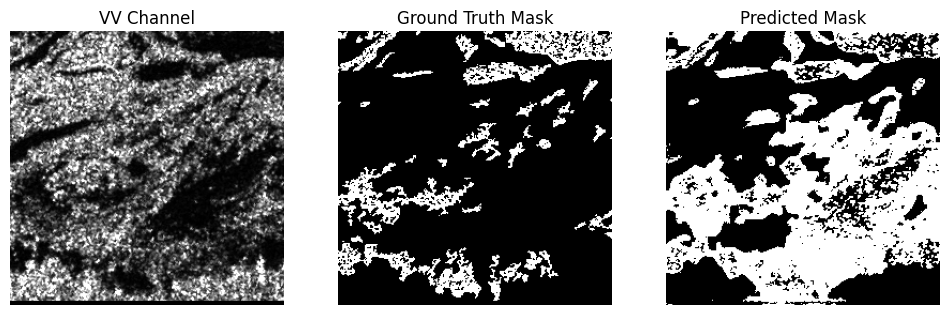

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


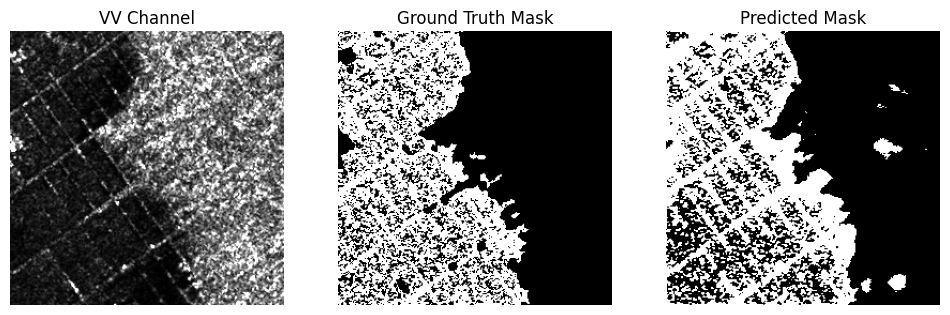

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


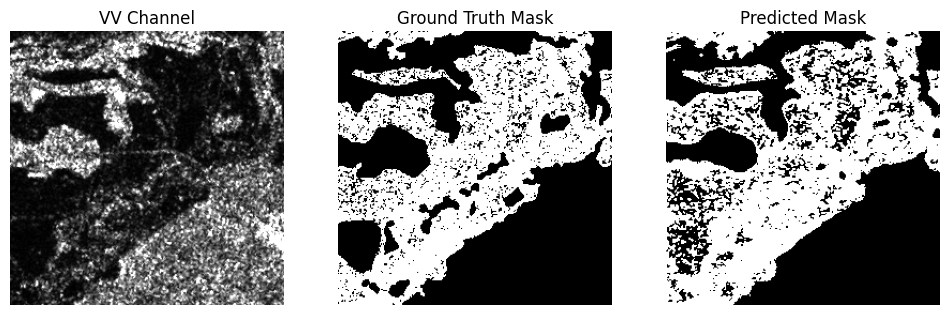

In [ ]:
# prompt: i want to make a code to visualize the prediction and the result of specific image

def visualize_prediction(idx):
  """Visualizes the prediction and ground truth for a specific image index.

  Args:
    idx: The index of the image in the test set.
  """

  mask = y_test[idx]
  prediction = res_model.predict(np.expand_dims(X_test[idx], axis=0))
  prediction = np.squeeze(prediction, axis=0)

  # Threshold the prediction to create a binary mask
  ret, thresh_pred = cv2.threshold(prediction, prediction.mean(), 1, cv2.THRESH_BINARY)
  ret2, mask = cv2.threshold(mask, 0.5, 1, cv2.THRESH_BINARY)

  plt.figure(figsize=(12, 4))

  plt.subplot(1, 3, 1)
  plt.imshow(X_test[idx][:,:,0], cmap='gray')
  plt.title('VV Channel')
  plt.axis('off')

  plt.subplot(1, 3, 2)
  plt.imshow(mask, cmap='gray')
  plt.title('Ground Truth Mask')
  plt.axis('off')

  plt.subplot(1, 3, 3)
  plt.imshow(thresh_pred, cmap='gray')
  plt.title('Predicted Mask')
  plt.axis('off')

  plt.show()


# Example usage: Visualize the prediction and ground truth for the 10th image in the test set
visualize_prediction(12)
visualize_prediction(18)
visualize_prediction(32)


In [ ]:
import pandas as pd
# Creating a Pandas DataFrame
data = {'accuracy': acc, 'precision': precision, 'recall': recall,  'f1': f1,  'jac': jac}
df = pd.DataFrame(data).dropna()

In [ ]:
df.describe().to_csv('r2unet.csv')

In [ ]:
res_model = Attention_UNet(input_shape)
res_model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])
res_model.summary()

res_model_results = res_model.fit(X_train, y_train, validation_split=0.1, batch_size=batch_size, epochs=epochs)


acc = []
precision =[]
recall = []
f1 = []
jac = []
k =[]

start5_test = datetime.now()

for idx in range(0,X_test.shape[0]):
    mask = y_test[idx]
    prediction = res_model.predict(np.expand_dims(X_test[idx], axis=0))
    prediction = np.squeeze(prediction, axis=0)
    ret, thresh_pred = cv2.threshold(prediction, prediction.mean(), 1, cv2.THRESH_BINARY)
    ret2, mask = cv2.threshold(mask, 0.5, 1, cv2.THRESH_BINARY)

    mask = list(mask.ravel())
    thresh_pred = list(thresh_pred.ravel())

    cm = confusion_matrix(mask, thresh_pred)

    if cm.shape == (2,2):
        #print(cm)

        TP = cm[0][0]
        FP = cm[0][1]
        FN = cm[1][0]
        TN = cm[1][1]

        accuracyscore = sklearn.metrics.accuracy_score(mask,thresh_pred)
        precisionscore = sklearn.metrics.precision_score(mask,thresh_pred, average='macro')
        recallscore = sklearn.metrics.recall_score(mask,thresh_pred, average='macro')
        f1score = 2*(precisionscore*recallscore)/(precisionscore + recallscore)
        jaccard = jaccard_score(mask,thresh_pred, average='macro')

            #print('stats ; ',idx, ';', accuracyscore, ';', precisionscore, ';', recallscore, ';', f1score, ';', jaccard, ';',kappa)
        acc.append(accuracyscore)
        precision.append(precisionscore)
        recall.append(recallscore)
        f1.append(f1score)
        jac.append(jaccard)

acc = np.array(acc)
precision = np.array(precision)
recall= np.array(recall)
f1 = np.array(f1)
jac = np.array(jac)
print("")
print("averages:","accuracy", np.average(acc), "precision", np.average(precision),"recall", np.average(recall),"f1", np.average(f1),"jac", np.average(jac))


Model: "Attention_UNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 256, 256, 2)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_47 (Conv2D)        │ (None, 256, 256, 16)   │            304 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_28    │ (None, 256, 256, 16)   │             64 │ conv2d_47[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_19             │ (None, 256, 256, 16)   │              0 │ batch_normalization_2… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_48 (Conv2D)        │ (None, 256, 256, 16)   │          2,320 │ activation_19[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_29    │ (None, 256, 256, 16)   │             64 │ conv2d_48[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_20             │ (None, 256, 256, 16)   │              0 │ batch_normalization_2… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_8           │ (None, 128, 128, 16)   │              0 │ activation_20[0][0]    │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_49 (Conv2D)        │ (None, 128, 128, 32)   │          4,640 │ max_pooling2d_8[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_30    │ (None, 128, 128, 32)   │            128 │ conv2d_49[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_21             │ (None, 128, 128, 32)   │              0 │ batch_normalization_3… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_50 (Conv2D)        │ (None, 128, 128, 32)   │          9,248 │ activation_21[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_31    │ (None, 128, 128, 32)   │            128 │ conv2d_50[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_22             │ (None, 128, 128, 32)   │              0 │ batch_normalization_3… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_9      

 Total params: 2,341,657 (8.93 MB)

 Trainable params: 2,337,751 (8.92 MB)

 Non-trainable params: 3,906 (15.26 KB)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.6392 - loss: 0.6605 - val_accuracy: 0.2659 - val_loss: 3.2913
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 397ms/step - accuracy: 0.7575 - loss: 0.5583 - val_accuracy: 0.7561 - val_loss: 0.5664
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 401ms/step - accuracy: 0.7691 - loss: 0.5490 - val_accuracy: 0.7561 - val_loss: 0.5661
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 400ms/step - accuracy: 0.7786 - loss: 0.5381 - val_accuracy: 0.7561 - val_loss: 0.5588
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 398ms/step - accuracy: 0.7757 - loss: 0.5240 - val_accuracy: 0.7561 - val_loss: 0.5552
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 396ms/step - accuracy: 0.7871 - loss: 0.5158 - val_accuracy: 0.7561 - val_loss: 0.6214
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 395ms/step - accuracy: 0.7759 - loss: 0.5201 - val_accuracy: 0.7561 - val_loss: 0.5483
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 395ms/step - accuracy: 0.7883 - loss: 0.4963 - val_accurac

Enter the index of the image you want to visualize: 12
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


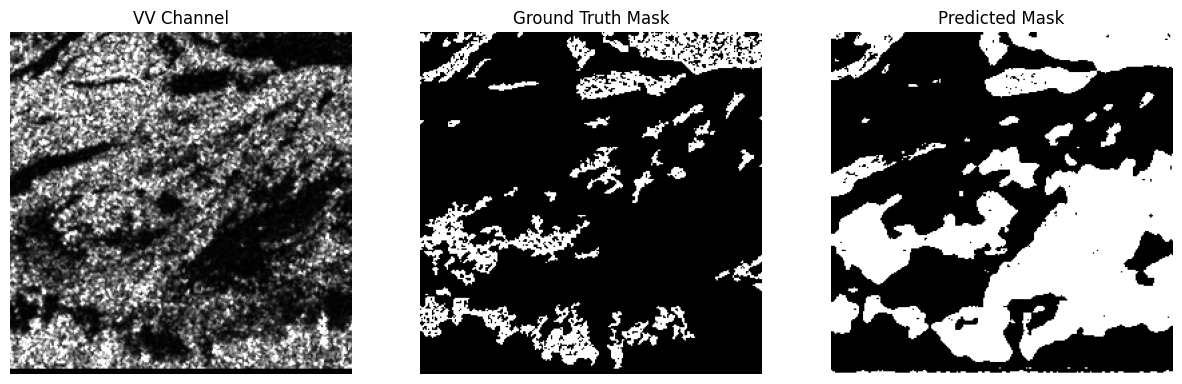

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


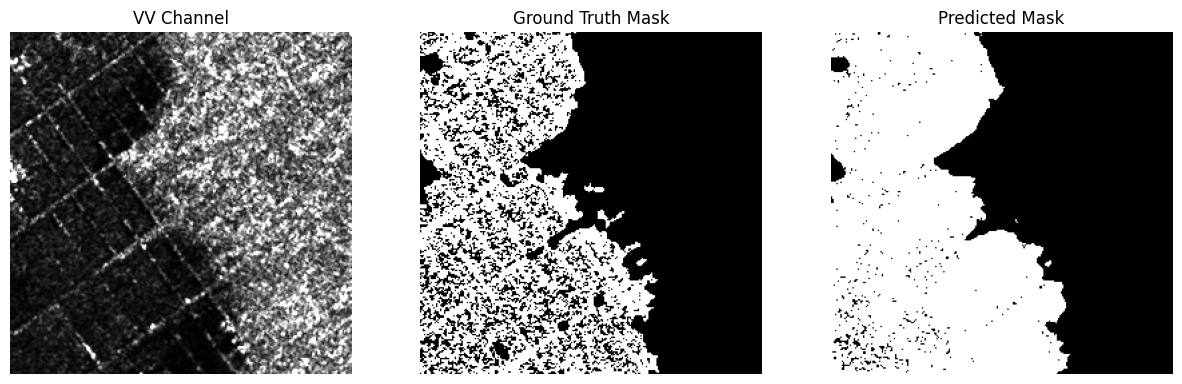

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


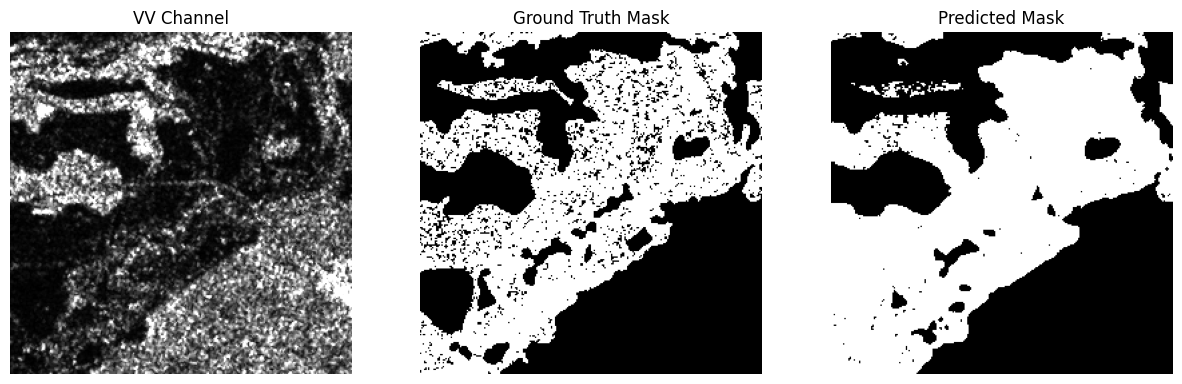

In [ ]:
# prompt: i want to make a code to visualize the prediction and the result of specific image

def visualize_specific_image(idx):
  """Visualizes the prediction and ground truth for a specific image index.

  Args:
    idx: The index of the image in the test set.
  """

  mask = y_test[idx]
  prediction = res_model.predict(np.expand_dims(X_test[idx], axis=0))
  prediction = np.squeeze(prediction, axis=0)

  # Threshold the prediction to create a binary mask
  ret, thresh_pred = cv2.threshold(prediction, prediction.mean(), 1, cv2.THRESH_BINARY)
  ret2, mask = cv2.threshold(mask, 0.5, 1, cv2.THRESH_BINARY)


  plt.figure(figsize=(15, 5))

  plt.subplot(1, 3, 1)
  plt.imshow(X_test[idx][:,:,0], cmap='gray')
  plt.title('VV Channel')
  plt.axis('off')

  plt.subplot(1, 3, 2)
  plt.imshow(mask, cmap='gray')
  plt.title('Ground Truth Mask')
  plt.axis('off')

  plt.subplot(1, 3, 3)
  plt.imshow(thresh_pred, cmap='gray')
  plt.title('Predicted Mask')
  plt.axis('off')

  plt.show()


# Example usage: Visualize the prediction and ground truth for the 10th image in the test set
#image_index = int(input("Enter the index of the image you want to visualize: "))  # Get the index from the user
visualize_specific_image(12)
visualize_specific_image(18)
visualize_specific_image(32)


In [ ]:
import pandas as pd
# Creating a Pandas DataFrame
data = {'accuracy': acc, 'precision': precision, 'recall': recall,  'f1': f1,  'jac': jac}
df = pd.DataFrame(data).dropna()

In [ ]:
df.describe().to_csv('att_unet.csv')

In [ ]:
res_model = Attention_ResUNet(input_shape)
res_model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])
res_model.summary()

res_model_results = res_model.fit(X_train, y_train, validation_split=0.1, batch_size=batch_size, epochs=epochs)


acc = []
precision =[]
recall = []
f1 = []
jac = []
k =[]

start5_test = datetime.now()

for idx in range(0,X_test.shape[0]):
    mask = y_test[idx]
    prediction = res_model.predict(np.expand_dims(X_test[idx], axis=0))
    prediction = np.squeeze(prediction, axis=0)
    ret, thresh_pred = cv2.threshold(prediction, prediction.mean(), 1, cv2.THRESH_BINARY)
    ret2, mask = cv2.threshold(mask, 0.5, 1, cv2.THRESH_BINARY)

    mask = list(mask.ravel())
    thresh_pred = list(thresh_pred.ravel())

    cm = confusion_matrix(mask, thresh_pred)

    if cm.shape == (2,2):
        #print(cm)

        TP = cm[0][0]
        FP = cm[0][1]
        FN = cm[1][0]
        TN = cm[1][1]

        accuracyscore = sklearn.metrics.accuracy_score(mask,thresh_pred)
        precisionscore = sklearn.metrics.precision_score(mask,thresh_pred, average='macro')
        recallscore = sklearn.metrics.recall_score(mask,thresh_pred, average='macro')
        f1score = 2*(precisionscore*recallscore)/(precisionscore + recallscore)
        jaccard = jaccard_score(mask,thresh_pred, average='macro')

            #print('stats ; ',idx, ';', accuracyscore, ';', precisionscore, ';', recallscore, ';', f1score, ';', jaccard, ';',kappa)
        acc.append(accuracyscore)
        precision.append(precisionscore)
        recall.append(recallscore)
        f1.append(f1score)
        jac.append(jaccard)

acc = np.array(acc)
precision = np.array(precision)
recall= np.array(recall)
f1 = np.array(f1)
jac = np.array(jac)
print("")
print("averages:","accuracy", np.average(acc), "precision", np.average(precision),"recall", np.average(recall),"f1", np.average(f1),"jac", np.average(jac))


Model: "AttentionResUNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3             │ (None, 256, 256, 2)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_86 (Conv2D)        │ (None, 256, 256, 16)   │            304 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_55    │ (None, 256, 256, 16)   │             64 │ conv2d_86[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_50             │ (None, 256, 256, 16)   │              0 │ batch_normalization_5… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_88 (Conv2D)        │ (None, 256, 256, 16)   │             48 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_87 (Conv2D)        │ (None, 256, 256, 16)   │          2,320 │ activation_50[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_57    │ (None, 256, 256, 16)   │             64 │ conv2d_88[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_56    │ (None, 256, 256, 16)   │             64 │ conv2d_87[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_13 (Add)              │ (None, 256, 256, 16)   │              0 │ batch_normalization_5… │
│                           │                        │                │ batch_normalization_5… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_51             │ (None, 256, 256, 16)   │              0 │ add_13[0][0]           │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_12          │ (None, 128, 128, 16)   │              0 │ activation_51[0][0]    │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_89 (Conv2D)        │ (None, 128, 128, 32)   │          4,640 │ max_pooling2d_12[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_58    │ (None, 128, 128, 32)   │            128 │ conv2d_89[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_52             │ (None, 128, 128, 32)   │              0 │ batch_normalization_5… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_91 (Conv2D)   

 Total params: 2,454,169 (9.36 MB)

 Trainable params: 2,448,791 (9.34 MB)

 Non-trainable params: 5,378 (21.01 KB)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.6609 - loss: 0.6476 - val_accuracy: 0.7561 - val_loss: 0.6125
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 15s 469ms/step - accuracy: 0.7613 - loss: 0.5525 - val_accuracy: 0.7561 - val_loss: 0.7445
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 15s 471ms/step - accuracy: 0.7733 - loss: 0.5386 - val_accuracy: 0.7561 - val_loss: 0.5709
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 15s 468ms/step - accuracy: 0.7853 - loss: 0.5246 - val_accuracy: 0.7561 - val_loss: 0.5899
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 15s 468ms/step - accuracy: 0.7921 - loss: 0.5109 - val_accuracy: 0.7561 - val_loss: 0.5768
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 15s 468ms/step - accuracy: 0.7897 - loss: 0.5072 - val_accuracy: 0.7561 - val_loss: 0.5519
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 15s 468ms/step - accuracy: 0.7972 - loss: 0.4942 - val_accuracy: 0.7485 - val_loss: 0.5539
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 15s 468ms/step - accuracy: 0.7972 - loss: 0.4880 - val_accurac

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


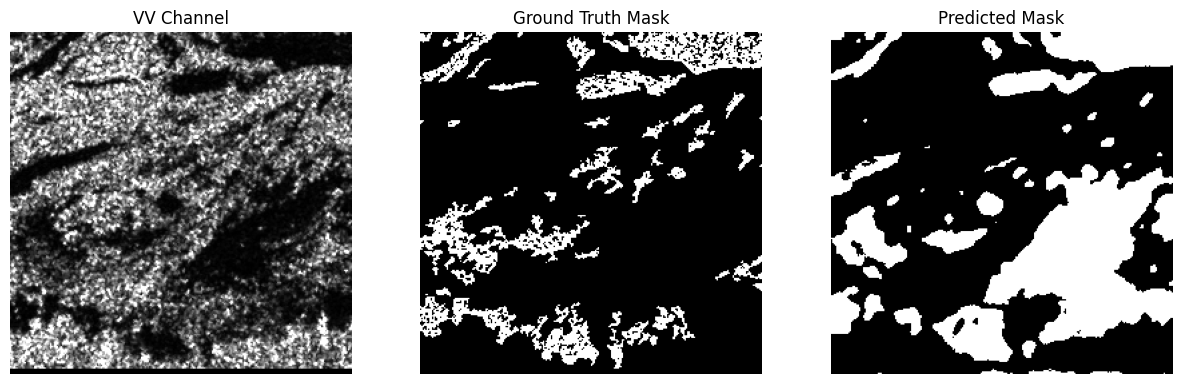

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


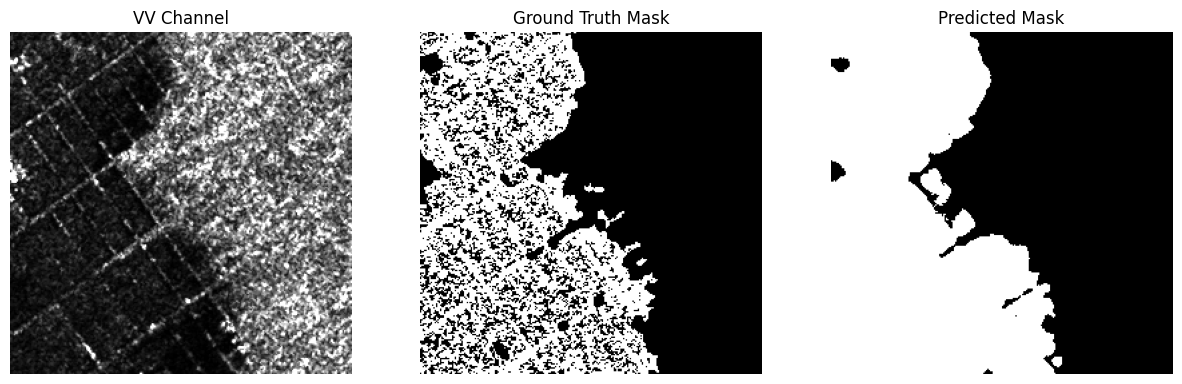

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


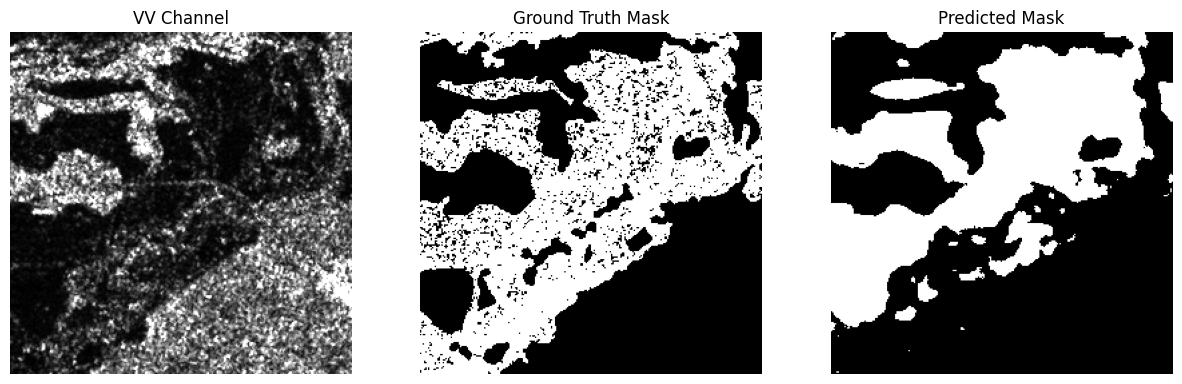

In [ ]:
# prompt: i want to make a code to visualize the prediction and the result of specific image

def visualize_specific_image(idx):
  """Visualizes the prediction and ground truth for a specific image index.

  Args:
    idx: The index of the image in the test set.
  """

  mask = y_test[idx]
  prediction = res_model.predict(np.expand_dims(X_test[idx], axis=0))
  prediction = np.squeeze(prediction, axis=0)

  # Threshold the prediction to create a binary mask
  ret, thresh_pred = cv2.threshold(prediction, prediction.mean(), 1, cv2.THRESH_BINARY)
  ret2, mask = cv2.threshold(mask, 0.5, 1, cv2.THRESH_BINARY)

  plt.figure(figsize=(15, 5))

  plt.subplot(1, 3, 1)
  plt.imshow(X_test[idx][:,:,0], cmap='gray')
  plt.title('VV Channel')
  plt.axis('off')

  plt.subplot(1, 3, 2)
  plt.imshow(mask, cmap='gray')
  plt.title('Ground Truth Mask')
  plt.axis('off')

  plt.subplot(1, 3, 3)
  plt.imshow(thresh_pred, cmap='gray')
  plt.title('Predicted Mask')
  plt.axis('off')

  plt.show()

# Example usage: Visualize the prediction and ground truth for a specific image
#image_index = int(input("Enter the index of the image you want to visualize: "))
visualize_specific_image(12)
visualize_specific_image(18)
visualize_specific_image(32)


In [ ]:
import pandas as pd
# Creating a Pandas DataFrame
data = {'accuracy': acc, 'precision': precision, 'recall': recall,  'f1': f1,  'jac': jac}
df = pd.DataFrame(data).dropna()

In [ ]:
df.describe().to_csv('att_resunet.csv')